# Control loop from a notebook

Talks to an Arduino running `ControlDemo` over [CtrlLink](../PROTOCOL.md): set gains,
step the reference, get the timeseries back as a DataFrame.

The board must be flashed first:

```
arduino-cli compile --fqbn arduino:avr:uno --libraries ./libraries ControlDemo
arduino-cli upload  --fqbn arduino:avr:uno -p <port> ControlDemo
```

**If a motor is connected**, the open-loop cells below will spin it. Check the bench
before running them.

In [143]:
!arduino-cli compile --fqbn arduino:avr:uno --libraries ../libraries ../ControlDemo
!arduino-cli upload  --fqbn arduino:avr:uno -p '/dev/cu.usbserial-110' ../ControlDemo

Sketch uses 13652 bytes (42%) of program storage space. Maximum is 32256 bytes.
Global variables use 427 bytes (20%) of dynamic memory, leaving 1621 bytes for local variables. Maximum is 2048 bytes.
OS error: cannot open port /dev/cu.usbserial-110: No such file or directory
Error: unable to open port /dev/cu.usbserial-110 for programmer arduino
Failed uploading: uploading error: exit status 1


In [144]:
import sys
sys.path.insert(0, '../python')

import numpy as np
import matplotlib.pyplot as plt
from ctrllink import CtrlLink

plt.rcParams['figure.figsize'] = (9, 3.5)
plt.rcParams['axes.grid'] = True

# Opening the port resets the board, so this takes a couple of seconds.
dev = CtrlLink()          # or CtrlLink('/dev/cu.usbserial-110')
print(dev.info)

CtrlLink 1 ControlDemo chans=4 row=21 dt_us=1000


## What the board says it has

Nothing here is hard-coded on the Python side. The device is asked what it exposes,
so a gain added to the sketch shows up below with no change to this notebook.

In [145]:
print('parameters:')
for name, value in dev.params.items():
    print(f'  {name:<9} {value}')

print('\ntelemetry channels:')
for c in dev.channels:
    print(f'  {c.name:<5} {c.type:<4} scale={c.scale:<12g} {c.unit}')

parameters:
  dec       1
  kp        0.1
  ki        0.0
  kd        0.1
  ref       40
  uff       0
  mode      2
  tickdiv   5
  maxlate   936

telemetry channels:
  ref   i16  scale=0.0878906    deg
  y     i16  scale=0.0878906    deg
  e     i16  scale=0.0878906    deg
  u     i16  scale=1            pwm


Parameters are plain attributes.

In [146]:
dev.kp = 2.5
print('kp is now', dev.kp)

# The value is read back and checked, so a mangled command cannot pass silently.
dev.kp = 0.5

kp is now 2.5


## Is the link healthy?

Run this before trusting any measurement. `drops` counts rows the board could not fit
into its transmit buffer; `gaps` counts breaks in the tick sequence from any cause.
Both should be zero.

In [147]:
# maxlate is a high-water mark that never resets by itself, so it still holds
# the delay caused by the parameter dump above. Zero it to measure the jitter of
# the streaming loop rather than of the last long reply.
dev.maxlate = 0

df = dev.capture(1.0)
span = df['t'].iloc[-1] - df['t'].iloc[0]

print(f'{len(df)} rows over {span:.3f} s  ->  {len(df)/span:.1f} Hz')
print(f'device sent {df.attrs["rows"]}, dropped {df.attrs["drops"]}, gaps {df.attrs["gaps"]}')
print(f'control period {df.attrs["dt_us"]} us, worst service delay {dev.maxlate} us')

df.head()

1001 rows over 1.000 s  ->  1001.0 Hz
device sent 1001, dropped 0, gaps 0
control period 1000 us, worst service delay 900 us


,t,ref,y,e,u
0,0.219,3.515624,348.749901,67.851543,255
1,0.220,3.515624,348.398338,71.718730,255
2,0.221,3.515624,39.199208,24.433587,0
3,0.222,3.515624,27.421867,39.726551,255
4,0.223,3.515624,18.984370,51.679673,255


In [148]:
row_bytes = 4 + sum(c.width for c in dev.channels) + 1
rate = 1e6 / df.attrs['dt_us']
used = row_bytes * rate / (1_000_000 / 10)

print(f'{row_bytes} bytes/row x {rate:.0f} Hz = {row_bytes*rate/1000:.1f} kB/s')
print(f'{used*100:.0f}% of the 1 Mbaud link')

21 bytes/row x 1000 Hz = 21.0 kB/s
21% of the 1 Mbaud link


## The sensor

`y` is the AS5600 angle. Turn the magnet by hand while this runs and the trace should
follow it; a flat line means the magnet is not moving (or is not there).

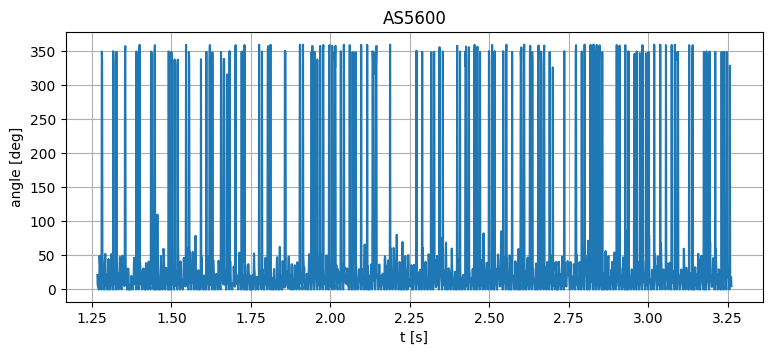

0.00 .. 359.82 deg,  sd 95.2457 deg


In [149]:
df = dev.capture(2.0)

plt.plot(df['t'], df['y'])
plt.xlabel('t [s]'); plt.ylabel('angle [deg]'); plt.title('AS5600')
plt.show()

print(f'{df["y"].min():.2f} .. {df["y"].max():.2f} deg,  sd {df["y"].std():.4f} deg')

## Open-loop step: identifying the plant

`mode = 0` bypasses the controller and puts `uff` straight on the actuator. Step it and
watch how the plant answers — that response is what the controller has to be designed
against.

`step()` holds for `pre` seconds, changes the parameter, then holds for `post`. The board
reports the exact tick the change landed on, so `t = 0` is the step itself, to the sample —
the host's timing jitter never enters the measurement.

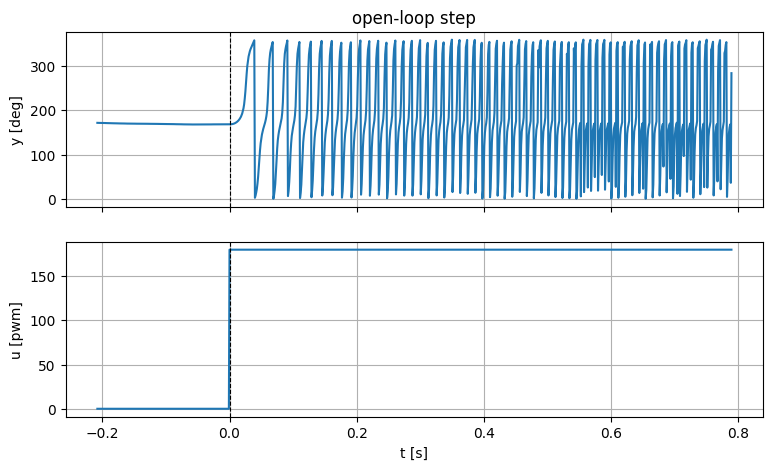

step recorded at tick [(56280, 'uff', '180')]
208 samples before, 791 after


In [158]:
dev.mode = 0
dev.uff = 0

df = dev.step('uff', 180, pre=0.2, post=0.8, back=0)

fig, (a, b) = plt.subplots(2, 1, sharex=True, figsize=(9, 5))
a.plot(df['t'], df['y']); a.set_ylabel('y [deg]')
b.plot(df['t'], df['u']); b.set_ylabel('u [pwm]'); b.set_xlabel('t [s]')
for ax in (a, b):
    ax.axvline(0, color='k', lw=0.8, ls='--')
a.set_title('open-loop step')
plt.show()

print('step recorded at tick', df.attrs['marks'])
print(f'{(df["t"] < 0).sum()} samples before, {(df["t"] >= 0).sum()} after')

## Closed-loop step response

`mode = 1` runs the PID. Step the reference and watch the loop close.

With no motor attached `y` will not move and `u` will simply saturate — that is the
controller doing exactly what it should against a plant that is not there.

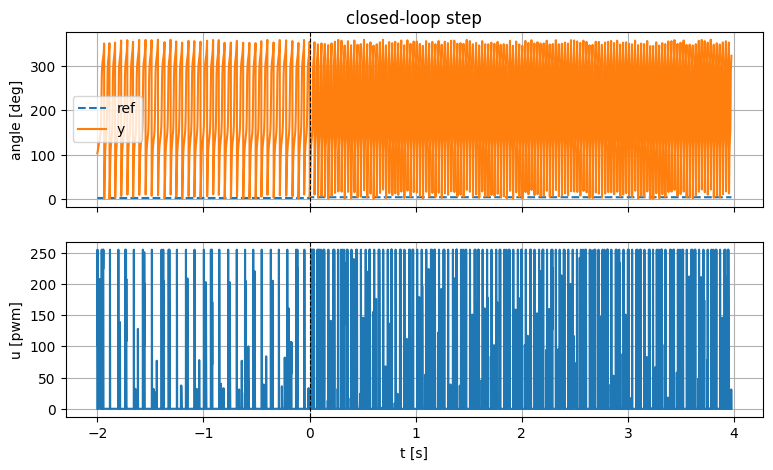

In [163]:
dev.mode = 0
dev.uff = 0 
y = int(dev.capture(0.1)['y'].iloc[-1])

dev.kp, dev.ki, dev.kd = 0.1, 0.1, 0.05
dev.uff = 0

#start = y  #int(y)
#dev.ref = 0
#df = dev.step('ref', start + 180 * 4096/360, pre=0.1, post=9.9, back=start)
#dev.mode = 0
#dev.uff = 0

dev.mode = 2
dev.ref = 20
df = dev.step('ref', 40, pre=2, post=4, back=0)
dev.mode = 0
#dev.uff = 0

fig, (a, b) = plt.subplots(2, 1, sharex=True, figsize=(9, 5))
a.plot(df['t'], df['ref'], label='ref', ls='--')
a.plot(df['t'], df['y'], label='y')
a.set_ylabel('angle [deg]'); a.legend()
b.plot(df['t'], df['u']); b.set_ylabel('u [pwm]'); b.set_xlabel('t [s]')
for ax in (a, b):
    ax.axvline(0, color='k', lw=0.8, ls='--')
a.set_title('closed-loop step')
plt.show()

## Sweeping a gain

The whole point of driving this from a notebook: change a gain, re-measure, overlay.
Each pass is one round trip to the board.

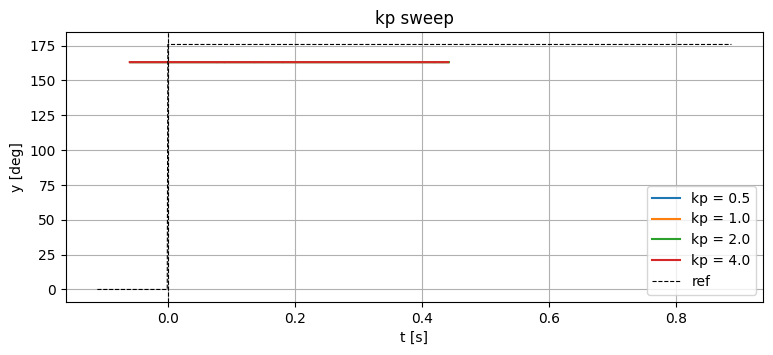

kp=0.5   rows=502   drops=0 gaps=0
kp=1.0   rows=502   drops=0 gaps=0
kp=2.0   rows=502   drops=0 gaps=0
kp=4.0   rows=502   drops=0 gaps=0


In [74]:
results = {}
start = int(dev.get('ref'))

for kp in (0.5, 1.0, 2.0, 4.0):
    dev.kp = kp
    results[kp] = dev.step('ref', start + 512, pre=0.05, post=0.45, back=start)

for kp, d in results.items():
    plt.plot(d['t'], d['y'], label=f'kp = {kp}')
plt.plot(df['t'], df['ref'], 'k--', lw=0.8, label='ref')
plt.axvline(0, color='k', lw=0.8, ls='--')
plt.xlabel('t [s]'); plt.ylabel('y [deg]'); plt.legend(); plt.title('kp sweep')
plt.show()

for kp, d in results.items():
    print(f'kp={kp:<5} rows={len(d):<5} drops={d.attrs["drops"]} gaps={d.attrs["gaps"]}')

## Changing the loop rate

`tickdiv` divides the 5 kHz sampler down to the control rate, so `tickdiv = 5` is 1 kHz
and `tickdiv = 50` is 100 Hz. Useful for showing what discretisation does to a loop that
was tuned at a different rate.

`dec` is separate: it thins the *telemetry* without touching the control rate, for when a
long run would otherwise outrun the link.

In [ ]:
dev.tickdiv = 25            # 5000 / 25 = 200 Hz
d = dev.capture(0.5)
print(f'tickdiv=25 -> period {d.attrs["dt_us"]} us, {len(d)/(d["t"].iloc[-1]-d["t"].iloc[0]):.0f} Hz')

dev.tickdiv = 5             # back to 1 kHz
d = dev.capture(0.5)
print(f'tickdiv=5  -> period {d.attrs["dt_us"]} us, {len(d)/(d["t"].iloc[-1]-d["t"].iloc[0]):.0f} Hz')

## Finishing up

Leave the actuator at rest and free the port, or the next `CtrlLink()` will find it busy.

In [ ]:
dev.mode = 0
dev.uff = 0
dev.close()
print('closed')